In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from matplotlib.collections import LineCollection
from src.results_paper import *
from src.TimeSeriesAnalysis import *
from src.process_data import process_all_roots, summarize_all_dirs
from IPython.display import clear_output

In [2]:
results_folder = "../results/Navigation/3D"
create_folder(results_folder)

In [ ]:
process_all_roots("../Data/bond_percolation", verbose=True, clean_outputs=False)
summarize_all_dirs("../Data/bond_percolation", verbose=True)
clear_output()

In [21]:
df = pd.read_csv("../Data/bond_percolation/all_data_3D.dat", sep=' ').sort_values('rho')
df

,L,Nt,k,nc,rho,p0,P0,order,N_samples,p_mean,p_err,shortest_path,shortest_path_err,S_perc,S_perc_err
2799,512,3000,0.000001,8,0.00997,1.0,0.1,8,50,0.258484,0.000078,1788.100,3.449371,6029710.000,10326.770562
2796,512,3000,0.000001,8,0.00997,1.0,0.1,5,50,0.256702,0.000081,1778.040,3.623839,6030314.040,10282.289067
2795,512,3000,0.000001,8,0.00997,1.0,0.1,4,50,0.256442,0.000082,1772.680,4.216628,6030394.920,10350.301604
2794,512,3000,0.000001,8,0.00997,1.0,0.1,3,50,0.256479,0.000080,1771.740,4.631640,6030063.980,10183.940155
2793,512,3000,0.000001,8,0.00997,1.0,0.1,2,50,0.256276,0.000084,1762.520,5.176496,6030083.400,10229.073391
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4022,256,3000,0.000001,2,0.50000,1.0,0.1,1,100,0.256731,0.000062,790.800,1.962631,3117258.750,5640.954449
4408,512,3000,0.000001,2,0.50000,1.0,0.1,1,50,0.250217,0.000060,2979.000,24.619372,9876858.880,65973.800474
4793,128,3000,0.000001,2,0.50000,1.0,0.1,2,500,0.394143,0.000561,144.928,0.183196,995073.066,3258.684044
4023,256,3000,0.000001,2,0.50000,1.0,0.1,2,100,0.256894,0.000067,798.020,1.846590,3117092.460,5648.742550


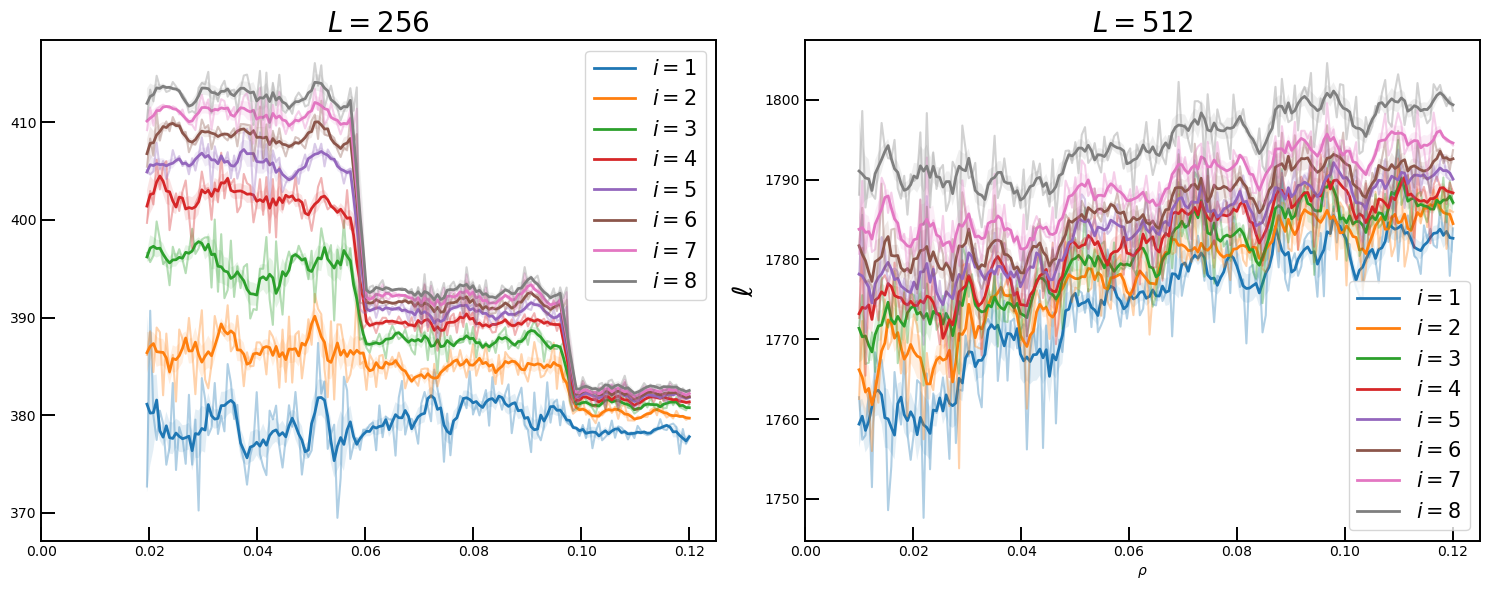

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

L = [256, 512]
nc = 8
orders = [i for i in range(1, nc+1)]
P0 = 0.1
p0 = 1.0
WINDOW = 5  # nº de pontos na janela (ajuste conforme quiser)
thickness_axes = 1.4
label_tick_size = 10
fig, axs = plt.subplots(1,2,figsize=(15,6))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
for idx, ax in enumerate(axs):
    count = 0
    for order in orders:
        df_f = df[(df["L"] == L[idx]) & (df["nc"] == nc) & (df["order"] == order) & (df["P0"]==P0) & (df["p0"]==p0)].copy()
        df_f = df_f.sort_values("rho")  # garante ordem crescente no eixo x

        x = df_f["rho"].to_numpy()
        y = df_f["shortest_path"].to_numpy()

        # média móvel centrada
        y_ma = (
            pd.Series(y)
            .rolling(window=WINDOW, center=True, min_periods=max(3, WINDOW//2))
            .mean()
            .to_numpy()
        )

        # desvio padrão na janela e erro padrão da média
        y_std = (
            pd.Series(y)
            .rolling(window=WINDOW, center=True, min_periods=max(3, WINDOW//2))
            .std()
            .to_numpy()
        )
        y_sem = y_std / np.sqrt(np.minimum(WINDOW, np.arange(1, len(y)+1)))  # aproxima

        # série original (mais clarinha) + média móvel
        ax.plot(x, y, alpha=0.35)
        ax.plot(x, y_ma, color=colors[count] ,linewidth=2, label=f"$i = {order}$")

        # faixa opcional de incerteza (comente se não quiser)
        ax.fill_between(x, y_ma - y_sem, y_ma + y_sem, alpha=0.12)
        ax.legend(fontsize=15)
        ax.set_title(f"$L = {L[idx]}$", fontsize=20)
        ax.set_xlim(0.0, 1/nc)
        count +=1
        ax.tick_params(axis='both', which='major', direction='in', length=10, width=thickness_axes, colors='black')
        ax.tick_params(axis='both', which='minor', direction='in', length=3, width=thickness_axes, colors='black')
        ax.tick_params('both', labelsize=label_tick_size)
        for spine in ax.spines.values():
            spine.set_linewidth(thickness_axes)

plt.xlabel(r"$\rho$")
#plt.axhline(y=0.24881182, xmin=0, xmax=0.5)
plt.ylabel(r"$\ell$", fontsize=20)
plt.xlim([0, 1/nc ])
plt.tight_layout()
plt.show()

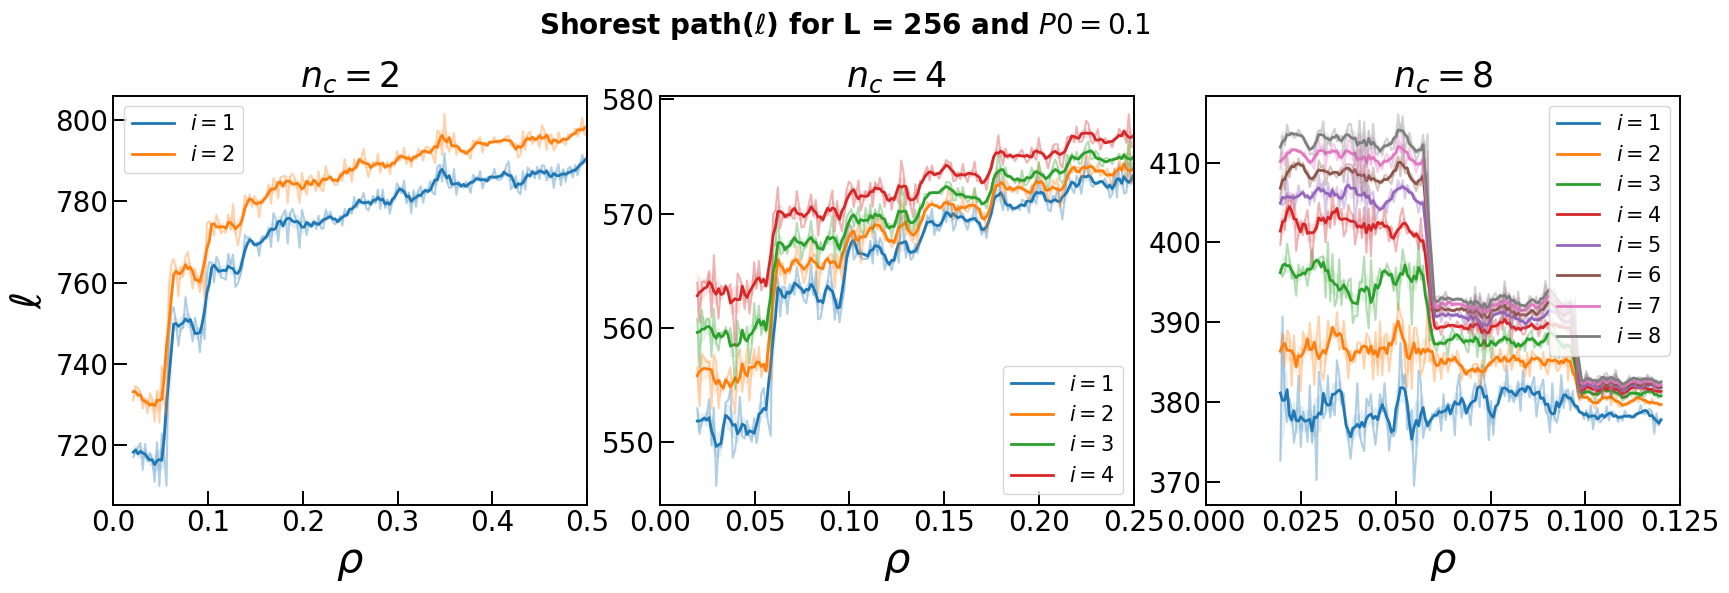

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

L = 256
NC_LIST = [2, 4, 8]
WINDOW = 5
P0 = 0.1
p0 = 1.0
#ylims = [(0.2550, 0.2575), (0.262, 0.272), (0.26, 0.36)]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
fig, axes = plt.subplots(1, 3, figsize=(17, 6), sharey=False)   # <<-- sem sharey
thickness_axes = 1.4

for ax, nc in zip(axes, NC_LIST):
    orders = [i for i in range(1, nc+1)]
    count = 0
    for order in orders:
        df_f = df[(df["L"] == L) & (df["nc"] == nc) & (df["order"] == order) & (df["P0"]==P0) & (df["p0"]==p0)].copy()
        if df_f.empty:
            continue
        df_f = df_f.sort_values("rho")

        x = df_f["rho"].to_numpy()
        y = df_f["shortest_path"].to_numpy()

        y_ma = (
            pd.Series(y).rolling(window=WINDOW, center=True, min_periods=max(3, WINDOW//2)).mean().to_numpy()
        )
        y_std = (
            pd.Series(y).rolling(window=WINDOW, center=True, min_periods=max(3, WINDOW//2)).std().to_numpy()
        )
        y_sem = y_std / np.sqrt(np.minimum(WINDOW, np.arange(1, len(y)+1)))

        ax.plot(x, y, alpha=0.35)
        ax.plot(x, y_ma, linewidth=2,color=colors[count] ,label=f"$i = {order}$")
        ax.fill_between(x, y_ma - y_sem, y_ma + y_sem, alpha=0.12)
        count += 1
    # limites e ticks específicos por painel
    #ax.set_ylim(ylim)
    #yticks = np.linspace(ylim[0], ylim[1], 6)           # ajuste o número de ticks se quiser
    #ax.set_yticks(yticks)
    #ax.set_yticklabels([f"${t:.3f}$" for t in yticks])
    
    ax.set_title(rf"$n_c = {nc}$",fontsize=25)
    ax.set_xlabel(r"$\rho$",fontsize=30)
    ax.set_xlim([0, 1/nc])
    ax.legend(fontsize=15)
    ax.tick_params(axis='both', which='major', direction='in', length=10, width=thickness_axes, labelsize=20)
    for spine in ax.spines.values():
        spine.set_linewidth(thickness_axes)
    
axes[0].set_ylabel(r"$\ell$",fontsize=30)
fig.suptitle(fr"Shorest path($\ell$) for L = {L} and $P0 = {P0}$", fontsize=20, fontweight='bold') # Adds a title to the entire figure
fig.tight_layout()
#plt.savefig(results_folder + "/pc_multi_L_nc.pdf")
plt.show()


/tmp/ipykernel_67101/2077102980.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_ = df_filter[(df_filter["order"]==ord) & (df_filter["L"] == l) & (df["P0"]==P0) & (df["p0"]==p0)]
/tmp/ipykernel_67101/2077102980.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_ = df_filter[(df_filter["order"]==ord) & (df_filter["L"] == l) & (df["P0"]==P0) & (df["p0"]==p0)]
/tmp/ipykernel_67101/2077102980.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_ = df_filter[(df_filter["order"]==ord) & (df_filter["L"] == l) & (df["P0"]==P0) & (df["p0"]==p0)]
/tmp/ipykernel_67101/2077102980.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_ = df_filter[(df_filter["order"]==ord) & (df_filter["L"] == l) & (df["P0"]==P0) & (df["p0"]==p0)]
/tmp/ipykernel_67101/2077102980.py:18: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_ = df_fi

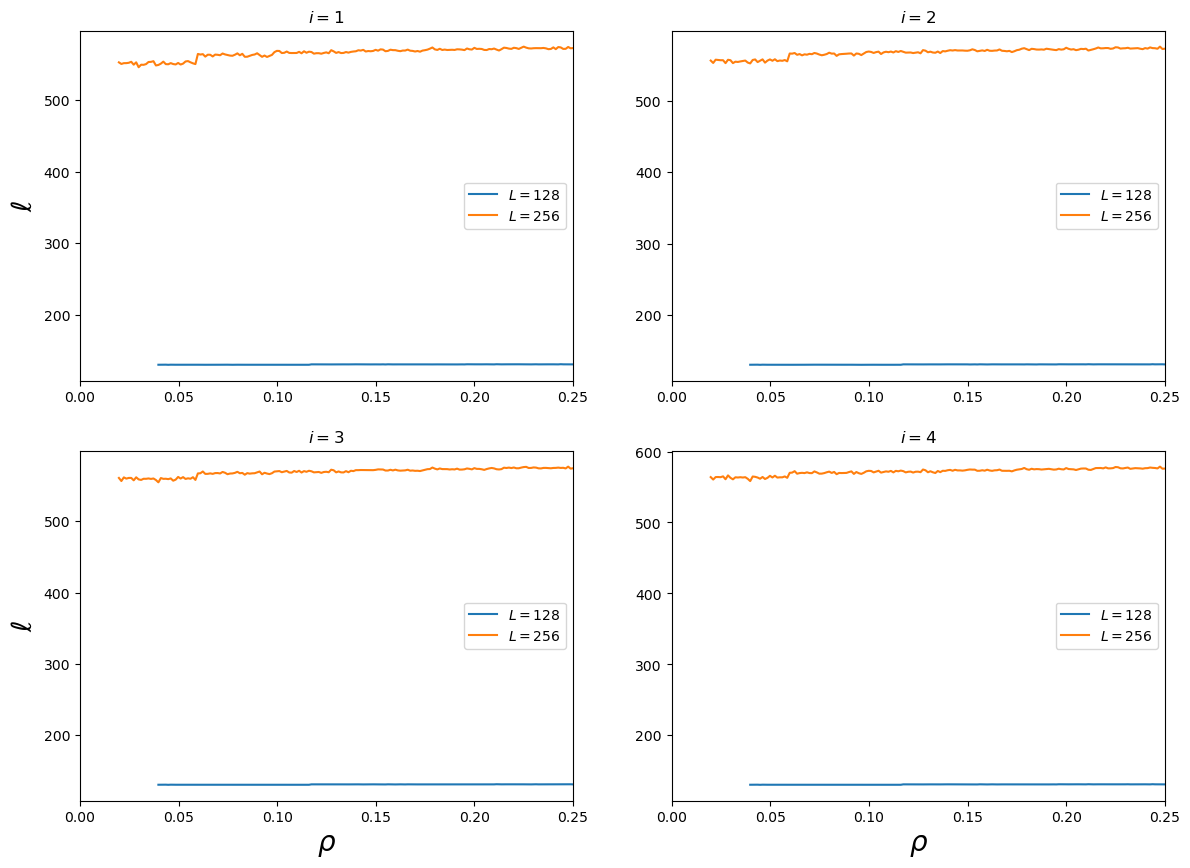

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

L = [128, 256]
Nc = 4
WINDOW = 5
P0 = 0.1
p0 = 1.0
orders = [i for i in range(1,5)]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
thickness_axes = 1.4
axs = [ax for ax in axes.flatten()]
df_filter = df[(df["nc"]==4) & (df["p0"]==1.0)]

for idx, ord in enumerate(orders):
    for l in L:
        df_ = df_filter[(df_filter["order"]==ord) & (df_filter["L"] == l) & (df["P0"]==P0) & (df["p0"]==p0)]
        axs[idx].plot(df_['rho'], df_['shortest_path'], label=f'$L = {l}$')

for idx, ax in enumerate(axs):
    ax.set_xlim(0, 0.25)
    ax.set_title(f"$i={idx+1}$")
    ax.legend()

for ax in axes[:,0]:
    ax.set_ylabel(r"$\ell$", fontsize=20)
for ax in axes[1,:]:
    ax.set_xlabel(r"$\rho$", fontsize=20)
plt.show()

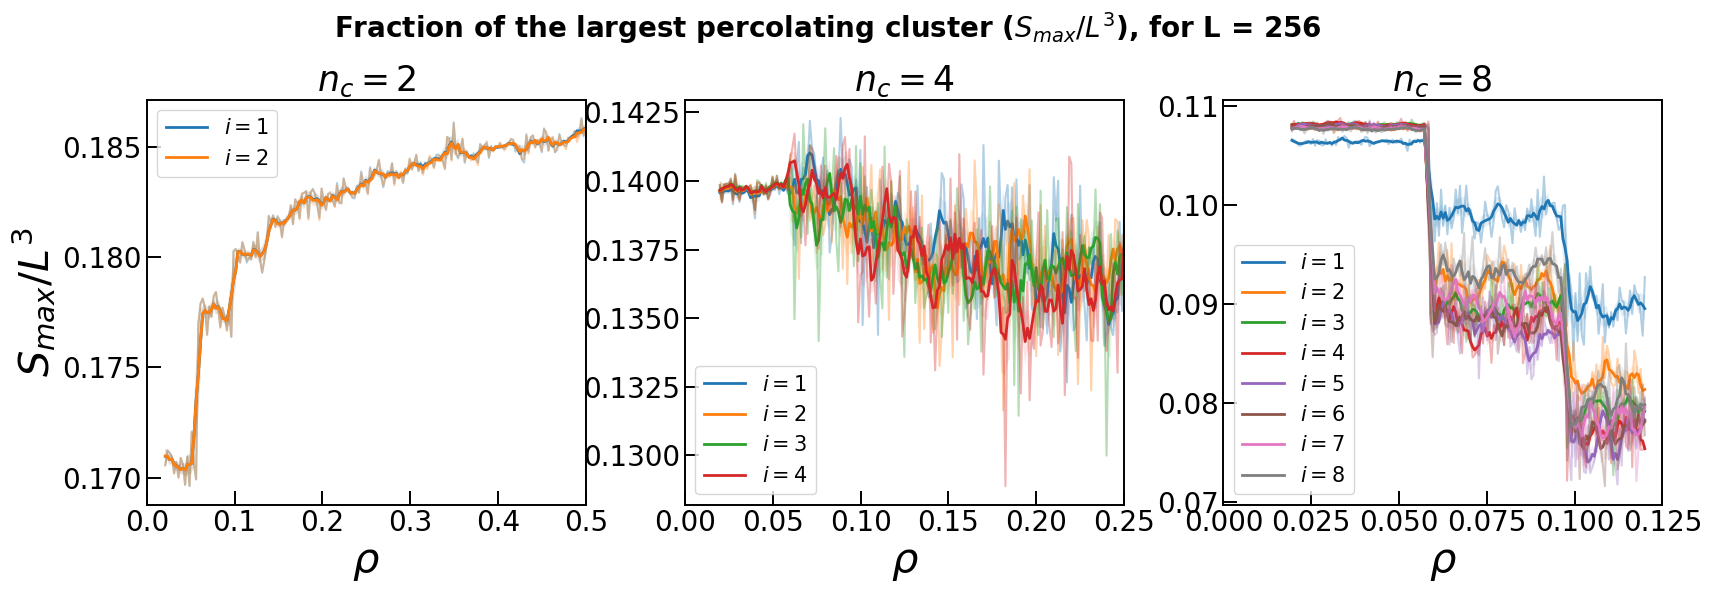

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

L = 256
VOL = L**3
NC_LIST = [2, 4, 8]
WINDOW = 5
P0 = 0.1
p0 = 1.0
#ylims = [(0.2550, 0.2575), (0.262, 0.272), (0.26, 0.36)]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']
fig, axes = plt.subplots(1, 3, figsize=(17, 6), sharey=False)   # <<-- sem sharey
thickness_axes = 1.4

for ax, nc in zip(axes, NC_LIST):
    orders = [i for i in range(1, nc+1)]
    count = 0
    for order in orders:
        df_f = df[(df["L"] == L) & (df["nc"] == nc) & (df["order"] == order) & (df["P0"]==P0) & (df["p0"]==p0)].copy()
        if df_f.empty:
            continue
        df_f = df_f.sort_values("rho")

        x = df_f["rho"].to_numpy()
        y = df_f["S_perc"].to_numpy()/VOL

        y_ma = (
            pd.Series(y).rolling(window=WINDOW, center=True, min_periods=max(3, WINDOW//2)).mean().to_numpy()
        )
        y_std = (
            pd.Series(y).rolling(window=WINDOW, center=True, min_periods=max(3, WINDOW//2)).std().to_numpy()
        )
        y_sem = y_std / np.sqrt(np.minimum(WINDOW, np.arange(1, len(y)+1)))

        ax.plot(x, y, alpha=0.35)
        ax.plot(x, y_ma, linewidth=2,color=colors[count] ,label=f"$i = {order}$")
        ax.fill_between(x, y_ma - y_sem, y_ma + y_sem, alpha=0.12)
        count += 1
    # limites e ticks específicos por painel
    #ax.set_ylim(ylim)
    #yticks = np.linspace(ylim[0], ylim[1], 6)           # ajuste o número de ticks se quiser
    #ax.set_yticks(yticks)
    #ax.set_yticklabels([f"${t:.3f}$" for t in yticks])
    
    ax.set_title(rf"$n_c = {nc}$",fontsize=25)
    ax.set_xlabel(r"$\rho$",fontsize=30)
    ax.set_xlim([0, 1/nc])
    ax.legend(fontsize=15)
    ax.tick_params(axis='both', which='major', direction='in', length=10, width=thickness_axes, labelsize=20)
    for spine in ax.spines.values():
        spine.set_linewidth(thickness_axes)
    
axes[0].set_ylabel(r"$S_{max}/L^3$",fontsize=30)
fig.suptitle(fr"Fraction of the largest percolating cluster ($S_{{max}}/L^3$), for L = {L}", fontsize=20, fontweight='bold') # Adds a title to the entire figure
fig.tight_layout()

#plt.savefig(results_folder + "/pc_multi_L_nc.pdf")
plt.show()


In [22]:
df

,L,Nt,k,nc,rho,p0,P0,order,N_samples,p_mean,p_err,shortest_path,shortest_path_err,S_perc,S_perc_err
2799,512,3000,0.000001,8,0.00997,1.0,0.1,8,50,0.258484,0.000078,1788.100,3.449371,6029710.000,10326.770562
2796,512,3000,0.000001,8,0.00997,1.0,0.1,5,50,0.256702,0.000081,1778.040,3.623839,6030314.040,10282.289067
2795,512,3000,0.000001,8,0.00997,1.0,0.1,4,50,0.256442,0.000082,1772.680,4.216628,6030394.920,10350.301604
2794,512,3000,0.000001,8,0.00997,1.0,0.1,3,50,0.256479,0.000080,1771.740,4.631640,6030063.980,10183.940155
2793,512,3000,0.000001,8,0.00997,1.0,0.1,2,50,0.256276,0.000084,1762.520,5.176496,6030083.400,10229.073391
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4022,256,3000,0.000001,2,0.50000,1.0,0.1,1,100,0.256731,0.000062,790.800,1.962631,3117258.750,5640.954449
4408,512,3000,0.000001,2,0.50000,1.0,0.1,1,50,0.250217,0.000060,2979.000,24.619372,9876858.880,65973.800474
4793,128,3000,0.000001,2,0.50000,1.0,0.1,2,500,0.394143,0.000561,144.928,0.183196,995073.066,3258.684044
4023,256,3000,0.000001,2,0.50000,1.0,0.1,2,100,0.256894,0.000067,798.020,1.846590,3117092.460,5648.742550


In [ ]:
L_lst = [128, 256, 512]
nc = 8
rho = 0.12
orders = [i for i in range(1,nc+1)]
for L in L_lst:
    df_filter = df[(df["nc"]==nc) & (df["rho"]==rho) & (df["L"]==L)]
    
    print(df_filter)

        L    Nt         k  nc   rho   p0   P0  order  N_samples    p_mean  \
2912  128  3000  0.000001   8  0.12  1.0  0.1      1        500  0.999739   
2913  128  3000  0.000001   8  0.12  1.0  0.1      2        500  0.999052   
2915  128  3000  0.000001   8  0.12  1.0  0.1      4        500  0.998979   
2914  128  3000  0.000001   8  0.12  1.0  0.1      3        500  0.995658   
2919  128  3000  0.000001   8  0.12  1.0  0.1      8        500  0.996800   
2918  128  3000  0.000001   8  0.12  1.0  0.1      7        500  0.996460   
2917  128  3000  0.000001   8  0.12  1.0  0.1      6        500  0.999755   
2916  128  3000  0.000001   8  0.12  1.0  0.1      5        500  0.996120   

         p_err  shortest_path  shortest_path_err      S_perc   S_perc_err  
2912  0.000008        127.258           0.024982  172762.266  3098.967678  
2913  0.000022        127.258           0.024982  172132.302  2934.505002  
2915  0.000028        127.256           0.024620  167274.284  2942.689440  
29